In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Classroom', 'Deborah Kaburu.jpg', 'Deborah Kaburu CV (2) (1).pdf', 'Deborah Kaburu CV (2).pdf', 'Cover Letter (4).pdf', 'BOOK CLUB info.gform', 'TT TERM 4 2025.xlsx', 'TERM 4 TT Version 3.xlsx', 'Deborah Kaburu CV.pdf', 'Deborah Kaburu CV .pdf', 'GLCPL_Pre-Lab Schedule_2025.pdf', 'Consent Form-Dentsu.pdf', 'Consent Form-Dentsu.gdoc', 'Deborah Dentsu.pdf', 'Deborah Dentsu.gdoc', 'Female Founders Academy project (2).zip', 'TERM 1 2026 TT.xlsx', 'WORK FLOW TERM 1 2026 TIMETABLE.docx', 'WORK FLOW TERM 1 2026 TIMETABLE.gdoc', 'TEACHER SUBJECT ALLOCATIONS PROPOSAL TERM 4 2025 (2).docx', 'TEACHER SUBJECT ALLOCATIONS PROPOSAL TERM 1 2026.docx', 'TEACHER SUBJECT ALLOCATIONS PROPOSAL TERM 1 2026.gdoc', '_MG_0030.jpg', 'New Hire - Employee Information Sheet Kenya 2022.xlsx', 'Bio Template.docx', 'New Hire - Employee Information Sheet Kenya 2022.gsheet', 'Bio Template.gdoc', 'Copy of Bio Template.gdoc', 'SOEA_password_template_updated.xlsx', 'Untitled document (6).gdoc', 'TERM 1 2026 TT V3 (1).x

In [4]:
dataset_path = "/content/drive/MyDrive/Food_Spoilage_Datasets"

print(os.listdir(dataset_path))

['archive (1).zip', 'Processed Data.zip']


In [5]:
import zipfile
import os

dataset_path = "/content/drive/MyDrive/Food_Spoilage_Datasets"

zip_files = [
    "archive (1).zip",
    "Processed Data.zip"
]

for zip_name in zip_files:
    zip_path = os.path.join(dataset_path, zip_name)

    print("\n" + "=" * 60)
    print(f"DATASET: {zip_name}")
    print("=" * 60)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()

        print(f"Total files inside ZIP: {len(files)}")
        print("\nFirst 40 entries:")

        for file in files[:40]:
            print(file)


DATASET: archive (1).zip
Total files inside ZIP: 12000

First 40 entries:
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (1).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (1).png
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (108).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (109).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (110).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (112).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (113).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (131).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (134).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (142).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (143).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (144).jpg
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (14

In [6]:
import zipfile
import os
from collections import Counter

dataset_path = "/content/drive/MyDrive/Food_Spoilage_Datasets"

zip_files = [
    "archive (1).zip",
    "Processed Data.zip"
]

for zip_name in zip_files:
    zip_path = os.path.join(dataset_path, zip_name)

    print("\n" + "=" * 70)
    print(f"DATASET: {zip_name}")
    print("=" * 70)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()

        image_files = [
            f for f in files
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        folders = Counter()

        for file in image_files:
            folder = os.path.dirname(file)
            folders[folder] += 1

        for folder, count in sorted(folders.items()):
            print(f"{folder}: {count} images")

        print(f"\nTOTAL IMAGES: {len(image_files)}")


DATASET: archive (1).zip
Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple: 612 images
Fruits_Vegetables_Dataset(12000)/Fruits/FreshBanana: 623 images
Fruits_Vegetables_Dataset(12000)/Fruits/FreshMango: 605 images
Fruits_Vegetables_Dataset(12000)/Fruits/FreshOrange: 609 images
Fruits_Vegetables_Dataset(12000)/Fruits/FreshStrawberry: 603 images
Fruits_Vegetables_Dataset(12000)/Fruits/RottenApple: 583 images
Fruits_Vegetables_Dataset(12000)/Fruits/RottenBanana: 573 images
Fruits_Vegetables_Dataset(12000)/Fruits/RottenMango: 593 images
Fruits_Vegetables_Dataset(12000)/Fruits/RottenOrange: 591 images
Fruits_Vegetables_Dataset(12000)/Fruits/RottenStrawberry: 596 images
Fruits_Vegetables_Dataset(12000)/Vegetables/FreshBellpepper: 611 images
Fruits_Vegetables_Dataset(12000)/Vegetables/FreshCarrot: 619 images
Fruits_Vegetables_Dataset(12000)/Vegetables/FreshCucumber: 608 images
Fruits_Vegetables_Dataset(12000)/Vegetables/FreshPotato: 614 images
Fruits_Vegetables_Dataset(12000)/Vegetables/Fre

In [7]:
import zipfile
import os
import re
from collections import defaultdict

zip_path = "/content/drive/MyDrive/Food_Spoilage_Datasets/Processed Data.zip"

source_images = defaultdict(set)
total_images = defaultdict(int)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for file in files:
        folder = os.path.dirname(file)
        filename = os.path.basename(file)

        # Remove augmentation prefix such as aug_101_
        original_name = re.sub(r'^aug_\d+_', '', filename)

        total_images[folder] += 1
        source_images[folder].add(original_name)

for folder in sorted(total_images):
    print("=" * 70)
    print(folder)
    print("Images:", total_images[folder])
    print("Estimated unique source filenames:", len(source_images[folder]))

Processed Data/Fresh Banana(1-4)
Images: 590
Estimated unique source filenames: 179
Processed Data/Fresh Bittermelon(1-3)
Images: 590
Estimated unique source filenames: 196
Processed Data/Fresh Cucumber(1-6)
Images: 590
Estimated unique source filenames: 140
Processed Data/Fresh Orange(1-9)
Images: 590
Estimated unique source filenames: 255
Processed Data/Fresh Papaya(1-4)
Images: 590
Estimated unique source filenames: 118
Processed Data/Fresh Tomato(1-10)
Images: 590
Estimated unique source filenames: 590
Processed Data/Fresh eggplant(1-4)
Images: 590
Estimated unique source filenames: 236
Processed Data/Fresh pineapple(1-15)
Images: 590
Estimated unique source filenames: 220
Processed Data/Rotten Bittermelon(5-8)
Images: 590
Estimated unique source filenames: 214
Processed Data/Rotten Cucumber(12-20)
Images: 590
Estimated unique source filenames: 47
Processed Data/Rotten Orange(20-35)
Images: 590
Estimated unique source filenames: 116
Processed Data/Rotten Papaya(7-12)
Images: 590
Es

In [8]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Food_Spoilage_Datasets/archive (1).zip"
extract_path = "/content/food_spoilage_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Fruits_Vegetables_Dataset(12000)']


## Training Progress Checkpoint

### Completed
- Google Colab environment configured
- TensorFlow 2.20.0 verified
- T4 GPU detected
- Google Drive mounted
- Two datasets uploaded to Google Drive
- 12K Fruits & Vegetables dataset inspected
- AgriFreshNET / Processed Data dataset inspected
- Dataset class counts examined
- Augmented-image/source structure in Processed Data investigated
- 12K dataset extracted to Colab `/content`

### Dataset 1
- 11,986 images
- 10 produce types
- 20 classes
- Fresh and Rotten labels

### Dataset 2
- 14,160 images
- 8 produce types
- Fresh, Semi-Fresh and Rotten
- Already contains augmented images
- Will NOT be randomly merged into baseline training

### Baseline Model Decision
Train the first custom CNN using the 12K dataset.

Supported produce:
Apple, Banana, Mango, Orange, Strawberry,
Bell Pepper, Carrot, Cucumber, Potato, Tomato.

Classification:
20 classes = produce type + Fresh/Rotten condition.

### NEXT STEP
Dataset quality inspection:
1. Check image dimensions and formats
2. Detect corrupt/unreadable images
3. Display sample fresh/rotten images
4. Check class balance
5. Create leakage-safe train/validation/test split
6. Apply augmentation to TRAINING data only
7. Build custom CNN

In [9]:
import os

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

if os.path.exists(dataset_path):
    print("Dataset is available.")
    print("Contents:", os.listdir(dataset_path))
else:
    print("Dataset is NOT available. We need to remount Drive and re-extract it.")

Dataset is available.
Contents: ['Fruits', 'Vegetables']


In [10]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

valid_extensions = (".jpg", ".jpeg", ".png")

image_sizes = Counter()
image_formats = Counter()

total_images = 0
valid_images = 0
corrupt_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:

        if file.lower().endswith(valid_extensions):
            total_images += 1
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

                # Re-open after verify() to safely read properties
                with Image.open(file_path) as img:
                    image_sizes[img.size] += 1
                    image_formats[img.format] += 1

                valid_images += 1

            except Exception as e:
                corrupt_images.append((file_path, str(e)))

print("DATASET QUALITY CHECK")
print("=" * 50)

print("Total image files:", total_images)
print("Valid images:", valid_images)
print("Corrupt/unreadable images:", len(corrupt_images))

print("\nImage formats:")
for image_format, count in image_formats.items():
    print(f"{image_format}: {count}")

print("\nMost common image dimensions:")
for size, count in image_sizes.most_common(10):
    print(f"{size}: {count} images")

print("\nNumber of different image dimensions:", len(image_sizes))

if corrupt_images:
    print("\nCorrupt files:")
    for file_path, error in corrupt_images[:20]:
        print(file_path)
        print("Error:", error)
else:
    print("\nNo corrupt images detected.")

DATASET QUALITY CHECK
Total image files: 11986
Valid images: 11986
Corrupt/unreadable images: 0

Image formats:
JPEG: 9573
PNG: 2409
WEBP: 3
MPO: 1

Most common image dimensions:
(224, 224): 4953 images
(100, 100): 1405 images
(320, 258): 988 images
(480, 322): 447 images
(275, 183): 387 images
(259, 194): 155 images
(848, 480): 142 images
(4032, 3024): 102 images
(262, 192): 91 images
(390, 280): 83 images

Number of different image dimensions: 1578

No corrupt images detected.


Dataset validation: 11,986 images inspected; 11,986 valid; 0 corrupt/unreadable; 1,578 unique image dimensions identified.

In [11]:
import os
from collections import OrderedDict

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

class_counts = OrderedDict()

for category in sorted(os.listdir(dataset_path)):
    category_path = os.path.join(dataset_path, category)

    if not os.path.isdir(category_path):
        continue

    for class_name in sorted(os.listdir(category_path)):
        class_path = os.path.join(category_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = sum(
            1 for file in os.listdir(class_path)
            if file.lower().endswith(valid_extensions)
        )

        class_counts[f"{category}/{class_name}"] = count


print("CLASS DISTRIBUTION")
print("=" * 55)

for class_name, count in class_counts.items():
    print(f"{class_name:<40} {count}")

print("=" * 55)
print("Number of classes:", len(class_counts))
print("Total images:", sum(class_counts.values()))

counts = list(class_counts.values())

print("Smallest class:", min(counts))
print("Largest class:", max(counts))
print("Difference:", max(counts) - min(counts))

CLASS DISTRIBUTION
Fruits/FreshApple                        612
Fruits/FreshBanana                       624
Fruits/FreshMango                        605
Fruits/FreshOrange                       609
Fruits/FreshStrawberry                   603
Fruits/RottenApple                       588
Fruits/RottenBanana                      576
Fruits/RottenMango                       593
Fruits/RottenOrange                      591
Fruits/RottenStrawberry                  596
Vegetables/FreshBellpepper               611
Vegetables/FreshCarrot                   620
Vegetables/FreshCucumber                 608
Vegetables/FreshPotato                   615
Vegetables/FreshTomato                   604
Vegetables/RottenBellpepper              591
Vegetables/RottenCarrot                  580
Vegetables/RottenCucumber                593
Vegetables/RottenPotato                  585
Vegetables/RottenTomato                  596
Number of classes: 20
Total images: 12000
Smallest class: 576
Largest class: 624


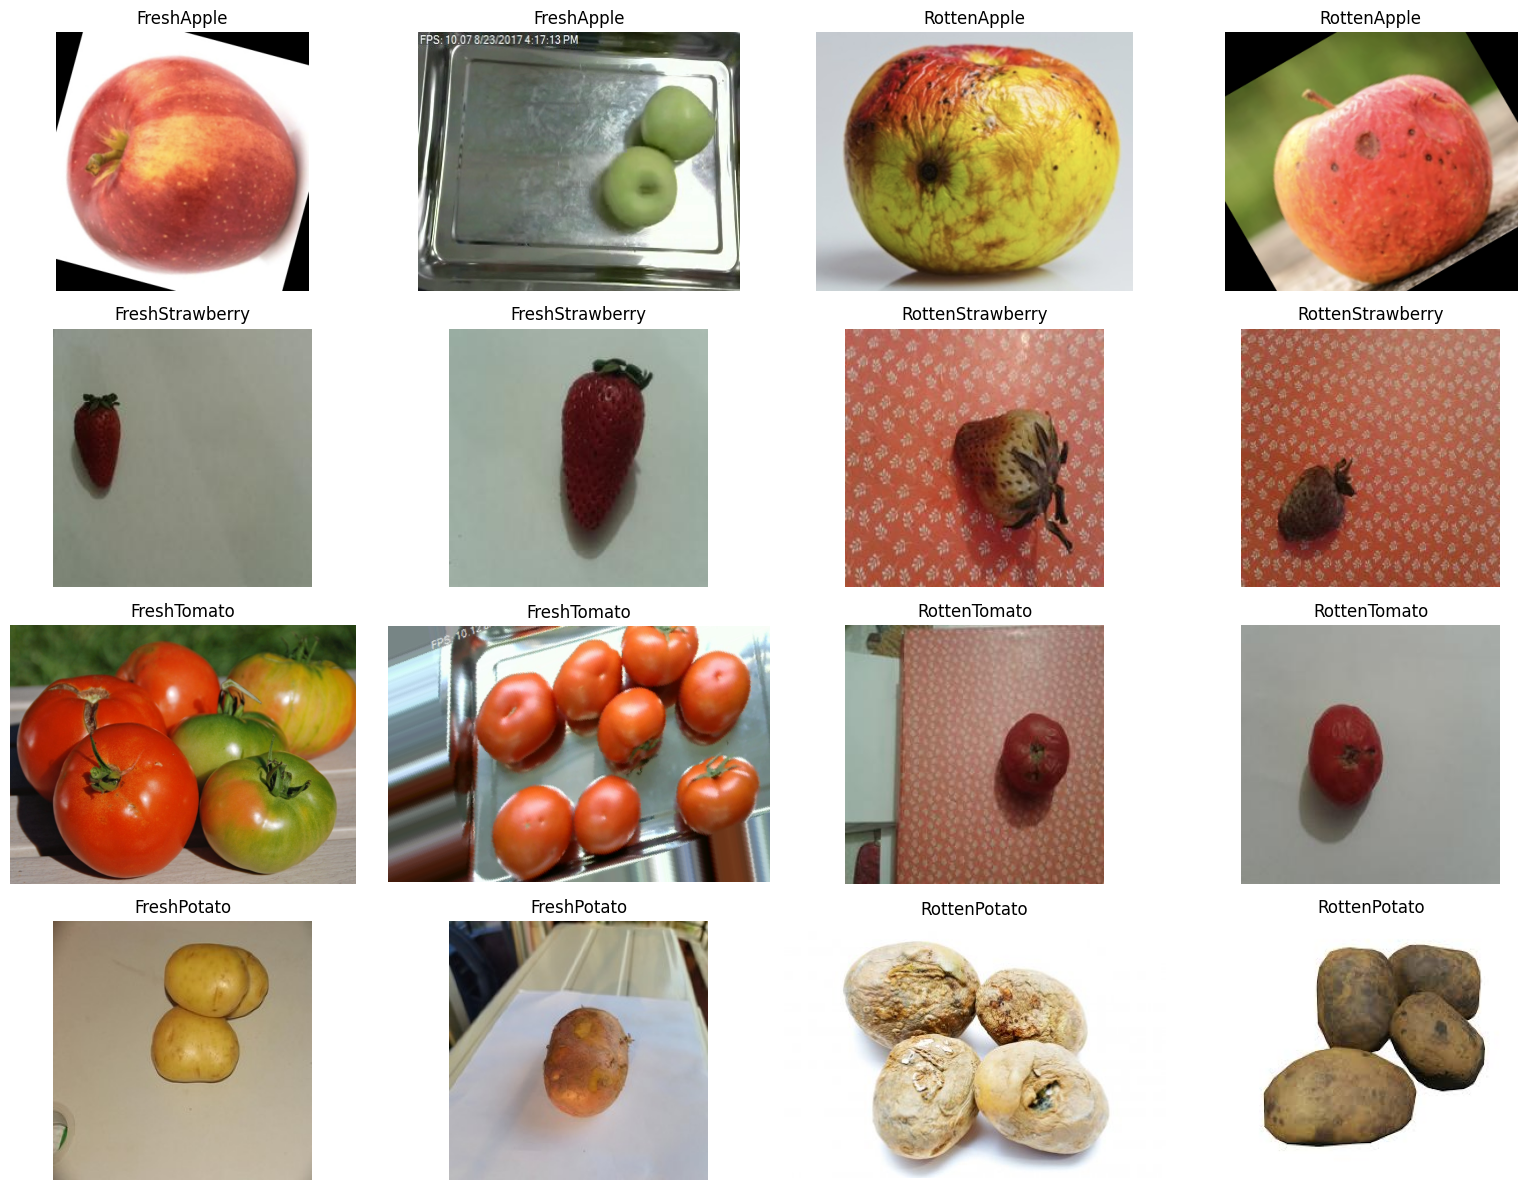

In [12]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

# Choose representative classes across fruits and vegetables
sample_classes = [
    ("Fruits", "FreshApple"),
    ("Fruits", "RottenApple"),
    ("Fruits", "FreshStrawberry"),
    ("Fruits", "RottenStrawberry"),
    ("Vegetables", "FreshTomato"),
    ("Vegetables", "RottenTomato"),
    ("Vegetables", "FreshPotato"),
    ("Vegetables", "RottenPotato"),
]

plt.figure(figsize=(16, 12))

plot_number = 1

for category, class_name in sample_classes:

    class_path = os.path.join(
        dataset_path,
        category,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp", ".mpo")
        )
    ]

    # Select two random images from each class
    selected_images = random.sample(image_files, 2)

    for image_file in selected_images:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path).convert("RGB")

            plt.subplot(4, 4, plot_number)
            plt.imshow(image)
            plt.title(class_name)
            plt.axis("off")

            plot_number += 1

        except Exception as e:
            print("Could not display:", image_path)
            print(e)

plt.tight_layout()
plt.show()

In [13]:
import os
import hashlib
from collections import defaultdict

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".mpo")

hash_groups = defaultdict(list)

for root, dirs, files in os.walk(dataset_path):
    for file in files:

        if file.lower().endswith(valid_extensions):
            file_path = os.path.join(root, file)

            try:
                with open(file_path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                hash_groups[file_hash].append(file_path)

            except Exception as e:
                print("Could not hash:", file_path)
                print(e)

duplicate_groups = {
    image_hash: paths
    for image_hash, paths in hash_groups.items()
    if len(paths) > 1
}

duplicate_files = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

print("DUPLICATE IMAGE CHECK")
print("=" * 50)
print("Total images checked:", sum(len(v) for v in hash_groups.values()))
print("Unique file hashes:", len(hash_groups))
print("Duplicate groups:", len(duplicate_groups))
print("Extra duplicate files:", duplicate_files)

if duplicate_groups:
    print("\nExample duplicate groups:")

    for i, paths in enumerate(list(duplicate_groups.values())[:10], start=1):
        print(f"\nGroup {i}:")
        for path in paths:
            print(" ", path)
else:
    print("\nNo exact duplicate images detected.")

DUPLICATE IMAGE CHECK
Total images checked: 12000
Unique file hashes: 11768
Duplicate groups: 224
Extra duplicate files: 232

Example duplicate groups:

Group 1:
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshBanana/freshBanana (422).jpg
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshBanana/freshBanana (1).webp

Group 2:
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (463).png
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (471).png

Group 3:
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (497).png
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (537).png

Group 4:
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (525).png
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Frui

In [14]:
import os
import hashlib
from collections import defaultdict

dataset_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".mpo")

hash_groups = defaultdict(list)

# Build duplicate groups again
for root, dirs, files in os.walk(dataset_path):
    for file in files:

        if file.lower().endswith(valid_extensions):
            file_path = os.path.join(root, file)

            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_groups[file_hash].append(file_path)


duplicate_groups = {
    image_hash: paths
    for image_hash, paths in hash_groups.items()
    if len(paths) > 1
}


same_class_duplicates = []
cross_class_duplicates = []

for image_hash, paths in duplicate_groups.items():

    classes = set()

    for path in paths:
        relative_path = os.path.relpath(path, dataset_path)

        parts = relative_path.split(os.sep)

        # Example:
        # Fruits/FreshApple/image.jpg
        # -> Fruits/FreshApple
        class_label = f"{parts[0]}/{parts[1]}"

        classes.add(class_label)

    if len(classes) == 1:
        same_class_duplicates.append((image_hash, paths))
    else:
        cross_class_duplicates.append(
            (image_hash, paths, classes)
        )


print("DUPLICATE LABEL ANALYSIS")
print("=" * 55)

print("Total duplicate groups:", len(duplicate_groups))
print("Same-class duplicate groups:", len(same_class_duplicates))
print("Cross-class duplicate groups:", len(cross_class_duplicates))


if cross_class_duplicates:

    print("\nWARNING: Cross-class duplicates detected!")

    for i, (image_hash, paths, classes) in enumerate(
        cross_class_duplicates[:20],
        start=1
    ):

        print(f"\nGroup {i}")
        print("Classes:", classes)

        for path in paths:
            print(" ", path)

else:
    print("\nNo duplicate images occur across different class labels.")

DUPLICATE LABEL ANALYSIS
Total duplicate groups: 224
Same-class duplicate groups: 222
Cross-class duplicate groups: 2


Group 1
Classes: {'Vegetables/RottenCarrot', 'Vegetables/FreshCarrot'}
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Vegetables/FreshCarrot/freshCarrot (534).jpg
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Vegetables/RottenCarrot/rottenCarrot (549).jpg
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Vegetables/RottenCarrot/rottenCarrot (31).jpg

Group 2
Classes: {'Vegetables/RottenCarrot', 'Vegetables/FreshCarrot'}
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Vegetables/FreshCarrot/freshCarrot (536).jpg
  /content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)/Vegetables/RottenCarrot/rottenCarrot (527).jpg


In [15]:
import os
import shutil
import hashlib
from collections import defaultdict

source_path = "/content/food_spoilage_dataset/Fruits_Vegetables_Dataset(12000)"
clean_path = "/content/clean_food_spoilage_dataset"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".mpo")

# Start clean
if os.path.exists(clean_path):
    shutil.rmtree(clean_path)

os.makedirs(clean_path)

# Group files by exact file hash
hash_groups = defaultdict(list)

for root, dirs, files in os.walk(source_path):
    for file in files:
        if file.lower().endswith(valid_extensions):

            file_path = os.path.join(root, file)

            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_groups[file_hash].append(file_path)


kept_images = 0
same_class_duplicates_removed = 0
conflicting_images_removed = 0
conflicting_groups_removed = 0


for image_hash, paths in hash_groups.items():

    labels = set()

    for path in paths:
        relative_path = os.path.relpath(path, source_path)
        parts = relative_path.split(os.sep)

        label = f"{parts[0]}/{parts[1]}"
        labels.add(label)

    # Conflicting labels:
    # exclude the entire duplicate group
    if len(labels) > 1:
        conflicting_groups_removed += 1
        conflicting_images_removed += len(paths)
        continue

    # Same label:
    # keep only ONE copy
    source_file = paths[0]
    relative_path = os.path.relpath(source_file, source_path)
    destination_file = os.path.join(clean_path, relative_path)

    os.makedirs(os.path.dirname(destination_file), exist_ok=True)

    shutil.copy2(source_file, destination_file)

    kept_images += 1
    same_class_duplicates_removed += len(paths) - 1


print("CLEAN DATASET CREATED")
print("=" * 55)

print("Original images:", sum(len(paths) for paths in hash_groups.values()))
print("Unique hashes:", len(hash_groups))

print("\nSame-class duplicate copies removed:",
      same_class_duplicates_removed)

print("Conflicting duplicate groups removed:",
      conflicting_groups_removed)

print("Images removed from conflicting groups:",
      conflicting_images_removed)

print("\nFinal cleaned dataset images:", kept_images)

print("\nClean dataset location:")
print(clean_path)

CLEAN DATASET CREATED
Original images: 12000
Unique hashes: 11768

Same-class duplicate copies removed: 229
Conflicting duplicate groups removed: 2
Images removed from conflicting groups: 5

Final cleaned dataset images: 11766

Clean dataset location:
/content/clean_food_spoilage_dataset


In [16]:
import os

clean_path = "/content/clean_food_spoilage_dataset"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".mpo")

clean_class_counts = {}

for category in sorted(os.listdir(clean_path)):

    category_path = os.path.join(clean_path, category)

    if not os.path.isdir(category_path):
        continue

    for class_name in sorted(os.listdir(category_path)):

        class_path = os.path.join(category_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = sum(
            1
            for file in os.listdir(class_path)
            if file.lower().endswith(valid_extensions)
        )

        clean_class_counts[f"{category}/{class_name}"] = count


print("CLEAN DATASET CLASS DISTRIBUTION")
print("=" * 60)

for class_name, count in clean_class_counts.items():
    print(f"{class_name:<42} {count}")

print("=" * 60)

counts = list(clean_class_counts.values())

print("Number of classes:", len(clean_class_counts))
print("Total cleaned images:", sum(counts))
print("Smallest class:", min(counts))
print("Largest class:", max(counts))
print("Difference:", max(counts) - min(counts))

CLEAN DATASET CLASS DISTRIBUTION
Fruits/FreshApple                          606
Fruits/FreshBanana                         623
Fruits/FreshMango                          605
Fruits/FreshOrange                         609
Fruits/FreshStrawberry                     603
Fruits/RottenApple                         586
Fruits/RottenBanana                        576
Fruits/RottenMango                         593
Fruits/RottenOrange                        591
Fruits/RottenStrawberry                    596
Vegetables/FreshBellpepper                 600
Vegetables/FreshCarrot                     608
Vegetables/FreshCucumber                   591
Vegetables/FreshPotato                     610
Vegetables/FreshTomato                     602
Vegetables/RottenBellpepper                547
Vegetables/RottenCarrot                    506
Vegetables/RottenCucumber                  576
Vegetables/RottenPotato                    564
Vegetables/RottenTomato                    574
Number of classes: 20
Total

In [17]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

clean_path = "/content/clean_food_spoilage_dataset"

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".mpo")

# Build a dataframe containing every image and its class
records = []

for category in sorted(os.listdir(clean_path)):

    category_path = os.path.join(clean_path, category)

    if not os.path.isdir(category_path):
        continue

    for class_name in sorted(os.listdir(category_path)):

        class_path = os.path.join(category_path, class_name)

        if not os.path.isdir(class_path):
            continue

        # Keep category in the label so classes remain unambiguous
        label = f"{category}/{class_name}"

        for file in os.listdir(class_path):

            if file.lower().endswith(valid_extensions):

                records.append({
                    "filepath": os.path.join(class_path, file),
                    "label": label
                })


df = pd.DataFrame(records)

print("Total cleaned images:", len(df))
print("Number of classes:", df["label"].nunique())


# ------------------------------------------------
# FIRST SPLIT
# 70% training
# 30% temporary set
# ------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


# ------------------------------------------------
# SECOND SPLIT
# Divide remaining 30% equally:
# 15% validation
# 15% testing
# ------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


print("\nDATASET SPLIT")
print("=" * 50)

print(f"Training images:   {len(train_df)} ({len(train_df)/len(df)*100:.2f}%)")
print(f"Validation images: {len(val_df)} ({len(val_df)/len(df)*100:.2f}%)")
print(f"Test images:       {len(test_df)} ({len(test_df)/len(df)*100:.2f}%)")

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))


print("\nCLASS COVERAGE")
print("=" * 50)

print("Classes in training:", train_df["label"].nunique())
print("Classes in validation:", val_df["label"].nunique())
print("Classes in test:", test_df["label"].nunique())


# Check for accidental overlap
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("\nOVERLAP CHECK")
print("=" * 50)

print("Train ↔ Validation:", len(train_paths.intersection(val_paths)))
print("Train ↔ Test:", len(train_paths.intersection(test_paths)))
print("Validation ↔ Test:", len(val_paths.intersection(test_paths)))

Total cleaned images: 11766
Number of classes: 20

DATASET SPLIT
Training images:   8236 (70.00%)
Validation images: 1765 (15.00%)
Test images:       1765 (15.00%)

Total: 11766

CLASS COVERAGE
Classes in training: 20
Classes in validation: 20
Classes in test: 20

OVERLAP CHECK
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


## Dataset Preparation Checkpoint

The initial dataset preparation and validation stage has been completed.

### Original Dataset
- Total images: 12,000
- Produce types: 10
- Classes: 20 (Fresh and Rotten for each produce type)
- Corrupt/unreadable images: 0
- Image dimensions identified: 1,578 different dimensions
- Original class range: 576–624 images per class

### Dataset Quality Findings
Visual inspection showed clear differences between many Fresh and Rotten samples, including changes in colour, texture, bruising, mould and visible deterioration.

Some differences in image backgrounds and photography styles were also observed. These may introduce dataset bias and will therefore be considered when evaluating model performance.

### Duplicate Analysis
Exact duplicate detection identified:
- 224 duplicate groups
- 232 additional duplicate files
- 222 same-class duplicate groups
- 2 cross-class conflicting duplicate groups

Same-class duplicates were reduced to one copy.

The 2 conflicting duplicate groups contained identical carrot images labelled as both Fresh and Rotten. All 5 images belonging to these conflicting groups were excluded rather than assigning an uncertain label.

### Cleaned Dataset
- Final images: 11,766
- Classes retained: 20
- Smallest class: 506 images
- Largest class: 623 images

The original dataset remains unchanged. All cleaning was performed on a separate working copy.

### Train / Validation / Test Split

A stratified 70/15/15 split was performed using `random_state=42` for reproducibility.

- Training: 8,236 images (70%)
- Validation: 1,765 images (15%)
- Testing: 1,765 images (15%)

All 20 classes are represented in each subset.

### Leakage Check

No filepath overlap was detected between:

- Training and Validation: 0
- Training and Test: 0
- Validation and Test: 0

The test set will remain untouched during model development and will only be used for final model evaluation.

### Next Stage

Image preprocessing and training-only data augmentation, followed by implementation of the custom CNN model.